# Install Libraries

In [2]:
# ── Install Dependencies ───────────────────────────────────────────────────────
!pip install pandas numpy matplotlib scikit-learn xgboost requests

# Imports

In [3]:
# ── Imports ────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
import time
import warnings
from datetime import datetime, timedelta
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

warnings.filterwarnings('ignore')
print("✅ Libraries loaded")

✅ Libraries loaded


# Configuration (API Key + Date Range)

In [6]:
# ── Configuration ──────────────────────────────────────────────────────────────
# Get a free EIA API key at: https://www.eia.gov/opendata/
EIA_API_KEY = "Input_Your_EIA_API_KEY"

# PJM region center (Philadelphia)
LAT, LON = 39.95, -75.16

# Date range — always pulls up to 2 days ago to account for EIA publication lag
START_DATE = "2022-01-01T00"
END_DATE   = (datetime.today() - timedelta(days=2)).strftime('%Y-%m-%dT00')

print(f"Date range: {START_DATE} → {END_DATE}")

Date range: 2022-01-01T00 → 2026-05-23T00


# Fetch Electricity Demand Data (EIA)

In [7]:
# ── Fetch PJM Electricity Demand (EIA API) ─────────────────────────────────────
# EIA enforces a 5,000 row per-request limit, so we paginate to get full history.

def fetch_eia_paginated(api_key, start, end, respondent='PJM'):
    all_data, offset, limit = [], 0, 5000
    while True:
        url = (
            "https://api.eia.gov/v2/electricity/rto/region-data/data/"
            f"?api_key={api_key}"
            "&frequency=hourly&data[0]=value"
            f"&facets[respondent][]={respondent}&facets[type][]=D"
            f"&start={start}&end={end}"
            "&sort[0][column]=period&sort[0][direction]=asc"
            f"&offset={offset}&length={limit}"
        )
        batch = requests.get(url).json()['response']['data']
        if not batch:
            break
        all_data.extend(batch)
        offset += limit
        print(f"   Fetched {len(all_data):,} rows...")
        time.sleep(0.5)  # respect EIA rate limits
    return all_data

raw = fetch_eia_paginated(EIA_API_KEY, START_DATE, END_DATE)

df = pd.DataFrame(raw)
df['period']    = pd.to_datetime(df['period'])
df['value']     = pd.to_numeric(df['value'])
df = (df.rename(columns={'period': 'datetime', 'value': 'demand_mwh'})
        [['datetime', 'demand_mwh']]
        .sort_values('datetime')
        .reset_index(drop=True))

print(f"\n✅ Demand data loaded: {len(df):,} rows")
print(f"   From: {df['datetime'].min()}")
print(f"   To:   {df['datetime'].max()}")

   Fetched 5,000 rows...
   Fetched 10,000 rows...
   Fetched 15,000 rows...
   Fetched 20,000 rows...
   Fetched 25,000 rows...
   Fetched 30,000 rows...
   Fetched 35,000 rows...
   Fetched 38,472 rows...

✅ Demand data loaded: 38,472 rows
   From: 2022-01-01 00:00:00
   To:   2026-05-23 00:00:00


# Fetch Weather Data (Open-Meteo)

In [8]:
# ── Fetch Weather Data (Open-Meteo — no API key needed) ───────────────────────
# Using Philadelphia as the PJM region center.
# Open-Meteo archive API has a data cap, so we cap at today minus 7 days.

weather_end = min(
    (datetime.today() - timedelta(days=7)).date(),
    datetime(2026, 5, 24).date()   # Open-Meteo archive hard cap
).strftime('%Y-%m-%d')

url = (
    f"https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={LAT}&longitude={LON}"
    f"&start_date=2022-01-01&end_date={weather_end}"
    f"&hourly=temperature_2m,relative_humidity_2m,windspeed_10m"
    f"&timezone=America/New_York"
)

wr = requests.get(url).json()

if 'hourly' in wr:
    weather_df = pd.DataFrame({
        'datetime': pd.to_datetime(wr['hourly']['time'], utc=True),
        'temp_c':    wr['hourly']['temperature_2m'],
        'humidity':  wr['hourly']['relative_humidity_2m'],
        'windspeed': wr['hourly']['windspeed_10m']
    })
    print(f"✅ Weather data loaded: {len(weather_df):,} rows")
else:
    weather_df = pd.DataFrame(columns=['datetime', 'temp_c', 'humidity', 'windspeed'])
    print(f"❌ Weather fetch failed: {wr.get('reason', 'Unknown error')}")

✅ Weather data loaded: 38,376 rows


# Merge Datasets & Engineer Features

In [13]:
# ── Merge & Feature Engineering ────────────────────────────────────────────────

# Convert 'datetime' column in df to UTC timezone-aware to match weather_df
df['datetime'] = df['datetime'].dt.tz_localize('America/New_York', nonexistent='shift_forward', ambiguous='NaT').dt.tz_convert('UTC')

merged = pd.merge(df, weather_df, on='datetime', how='inner')

# Time features
merged['hour']       = merged['datetime'].dt.hour
merged['day_of_week'] = merged['datetime'].dt.dayofweek
merged['month']      = merged['datetime'].dt.month
merged['is_weekend'] = (merged['day_of_week'] >= 5).astype(int)

# Demand lag features (autocorrelation signals)
merged['demand_lag_24h']    = merged['demand_mwh'].shift(24)    # same hour yesterday
merged['demand_lag_168h']   = merged['demand_mwh'].shift(168)   # same hour last week
merged['demand_rolling_24h'] = merged['demand_mwh'].rolling(24).mean()

# Temperature forecast proxy (simulates grid operator weather forecasts)
merged['temp_lead_6h']  = merged['temp_c'].shift(-6)
merged['temp_lead_12h'] = merged['temp_c'].shift(-12)

# Heat index (better spike signal than temperature alone)
merged['heat_index'] = (
    -8.78469475556
    + 1.61139411 * merged['temp_c']
    + 2.33854883889 * merged['humidity']
    - 0.14611605 * merged['temp_c'] * merged['humidity']
)

# Extreme weather flags
merged['is_heat_spike'] = (merged['temp_c'] > merged['temp_c'].quantile(0.90)).astype(int)
merged['is_cold_spike'] = (merged['temp_c'] < merged['temp_c'].quantile(0.10)).astype(int)

# Demand momentum and deviation
merged['demand_momentum']   = merged['demand_mwh'].diff(6)
merged['rolling_deviation'] = merged['demand_rolling_24h'] - merged['demand_mwh'].rolling(168).mean()
merged['temp_squared']      = merged['temp_c'] ** 2

merged = merged.dropna().reset_index(drop=True)
print(f"✅ Feature matrix ready: {merged.shape}")
merged.head()

✅ Feature matrix ready: (37446, 20)


,datetime,demand_mwh,temp_c,humidity,windspeed,hour,day_of_week,month,is_weekend,demand_lag_24h,demand_lag_168h,demand_rolling_24h,temp_lead_6h,temp_lead_12h,heat_index,is_heat_spike,is_cold_spike,demand_momentum,rolling_deviation,temp_squared
0,2022-01-08 05:00:00+00:00,119525.0,-7.2,65,12.3,5,5,1,1,112681.0,86665.0,107893.375,-5.4,-3.2,200.001254,0,1,7685.0,12786.363095,51.84
1,2022-01-08 06:00:00+00:00,118278.0,-7.3,65,12.7,6,5,1,1,111222.0,84516.0,108187.375,-4.1,-7.0,200.789868,0,1,7602.0,12879.398810,53.29
2,2022-01-08 07:00:00+00:00,116700.0,-7.9,64,11.2,7,5,1,1,109104.0,81848.0,108503.875,-3.1,-7.5,202.028692,0,1,7041.0,12988.446429,62.41
3,2022-01-08 08:00:00+00:00,114199.0,-7.2,64,10.5,8,5,1,1,106225.0,79441.0,108836.125,-2.3,-5.3,196.610669,0,1,4346.0,13113.803571,51.84
4,2022-01-08 09:00:00+00:00,110655.0,-9.0,67,7.7,9,5,1,1,102204.0,76489.0,109188.250,-2.0,-3.5,221.503509,0,1,-1984.0,13262.559524,81.00


# Train XGBoost Model

In [14]:
# ── Train XGBoost Forecast Model ───────────────────────────────────────────────

FEATURES = [
    'hour', 'day_of_week', 'month', 'is_weekend',
    'temp_c', 'temp_squared', 'humidity', 'windspeed',
    'heat_index', 'is_heat_spike', 'is_cold_spike',
    'demand_lag_24h', 'demand_lag_168h', 'demand_rolling_24h',
    'demand_momentum', 'rolling_deviation',
    'temp_lead_6h', 'temp_lead_12h'
]

X = merged[FEATURES]
y = merged['demand_mwh']

# Chronological 80/20 split — never shuffle time series data
split   = int(len(merged) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = xgb.XGBRegressor(
    n_estimators=700, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_alpha=0.05, reg_lambda=1.0,
    random_state=42, early_stopping_rounds=50
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

preds = model.predict(X_test)
mae   = mean_absolute_error(y_test, preds)
rmse  = np.sqrt(mean_squared_error(y_test, preds))
mape  = np.mean(np.abs((y_test - preds) / y_test)) * 100

print(f"\n✅ MAE:  {mae:,.0f} MWh  (avg hourly error)")
print(f"✅ RMSE: {rmse:,.0f} MWh  (penalizes large errors more)")
print(f"✅ MAPE: {mape:.2f}%      (% error vs actual)")

[0]	validation_0-rmse:15802.91140
[100]	validation_0-rmse:3070.87716
[200]	validation_0-rmse:2745.94891
[300]	validation_0-rmse:2626.10564
[400]	validation_0-rmse:2555.04499
[500]	validation_0-rmse:2503.90414
[600]	validation_0-rmse:2469.86518
[699]	validation_0-rmse:2447.13303

✅ MAE:  1,878 MWh  (avg hourly error)
✅ RMSE: 2,447 MWh  (penalizes large errors more)
✅ MAPE: 1.90%      (% error vs actual)


# Visualizations

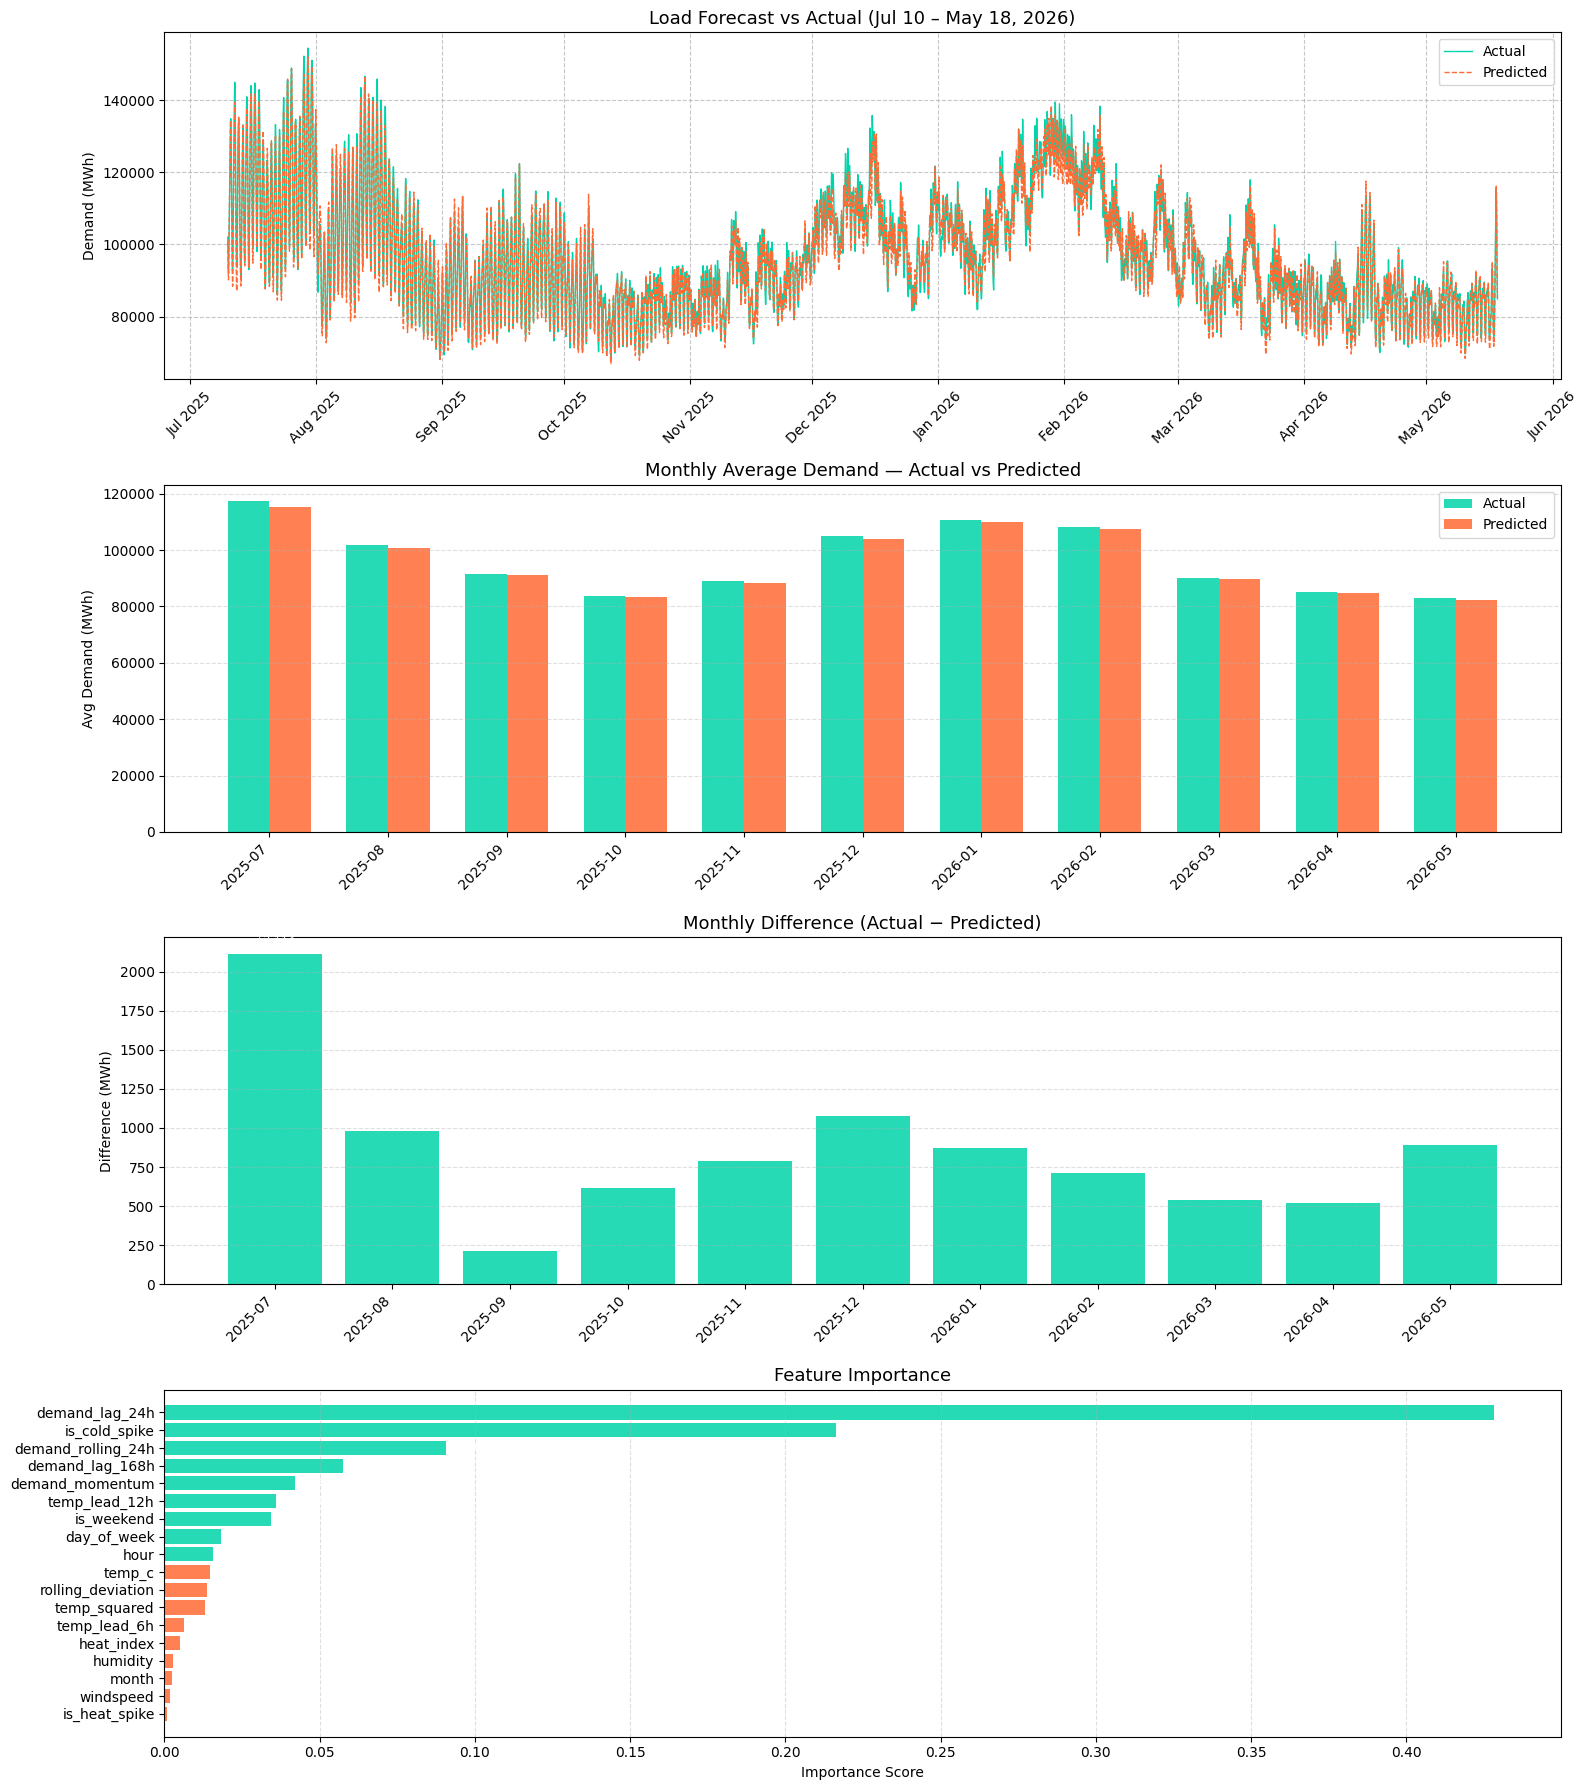


📊 Monthly Summary:
  Month  Actual (MWh)  Predicted (MWh)  Difference
2025-07 117299.040462    115184.812500 2114.227962
2025-08 101637.318548    100655.867188  981.451361
2025-09  91393.069444     91179.718750  213.350694
2025-10  83857.251344     83238.632812  618.618532
2025-11  89111.920613     88323.000000  788.920613
2025-12 105146.162634    104071.429688 1074.732947
2026-01 110712.659946    109838.078125  874.581821
2026-02 108071.389881    107360.906250  710.483631
2026-03  90188.228188     89647.632812  540.595375
2026-04  85205.418056     84684.140625  521.277431
2026-05  83052.742857     82159.351562  893.391295

✅ MAPE: 1.90%

🔍 Top 3 Most Important Features:
  demand_lag_24h: 0.4284
  is_cold_spike: 0.2162
  demand_rolling_24h: 0.0908


In [15]:
# ── Visualizations ─────────────────────────────────────────────────────────────

test_dates  = merged['datetime'].iloc[split:].reset_index(drop=True)
date_start  = test_dates.min().strftime('%b %d')
date_end    = test_dates.max().strftime('%b %d, %Y')

monthly = pd.DataFrame({'datetime': test_dates, 'actual': y_test.values, 'predicted': preds})
monthly['month']    = monthly['datetime'].dt.to_period('M')
monthly_agg         = monthly.groupby('month')[['actual', 'predicted']].mean().reset_index()
monthly_agg['month_str']   = monthly_agg['month'].astype(str)
monthly_agg['difference']  = monthly_agg['actual'] - monthly_agg['predicted']

x, width = np.arange(len(monthly_agg)), 0.35
fig, axes = plt.subplots(4, 1, figsize=(16, 18))

# Plot 1: Full test set — actual vs predicted
axes[0].plot(test_dates, y_test.values, label='Actual',    color='#00D4AA', linewidth=1.0)
axes[0].plot(test_dates, preds,         label='Predicted', color='#FF6B35', linewidth=1.0, linestyle='--')
axes[0].set_title(f'Load Forecast vs Actual ({date_start} – {date_end})', fontsize=13)
axes[0].set_ylabel('Demand (MWh)')
axes[0].legend()
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Monthly average — actual vs predicted
axes[1].bar(x - width/2, monthly_agg['actual'],    width, label='Actual',    color='#00D4AA', alpha=0.85)
axes[1].bar(x + width/2, monthly_agg['predicted'], width, label='Predicted', color='#FF6B35', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(monthly_agg['month_str'], rotation=45, ha='right')
axes[1].set_title('Monthly Average Demand — Actual vs Predicted', fontsize=13)
axes[1].set_ylabel('Avg Demand (MWh)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4, axis='y')

# Plot 3: Monthly difference (positive = model under-predicted)
diff_colors = ['#00D4AA' if d >= 0 else '#FF6B35' for d in monthly_agg['difference']]
axes[2].bar(x, monthly_agg['difference'], color=diff_colors, alpha=0.85)
axes[2].axhline(0, color='white', linewidth=0.8, linestyle='--')
axes[2].set_xticks(x)
axes[2].set_xticklabels(monthly_agg['month_str'], rotation=45, ha='right')
axes[2].set_title('Monthly Difference (Actual − Predicted)', fontsize=13)
axes[2].set_ylabel('Difference (MWh)')
axes[2].grid(True, linestyle='--', alpha=0.4, axis='y')
for i, diff in enumerate(monthly_agg['difference']):
    axes[2].text(i, diff + (50 if diff >= 0 else -50), f'{diff:+,.0f}',
                 ha='center', va='bottom' if diff >= 0 else 'top', fontsize=8, color='white')

# Plot 4: Feature importance (green = above median, orange = below)
feat_imp    = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
fi_colors   = ['#00D4AA' if v >= feat_imp.median() else '#FF6B35' for v in feat_imp]
axes[3].barh(feat_imp.index, feat_imp.values, color=fi_colors, alpha=0.85)
axes[3].set_title('Feature Importance', fontsize=13)
axes[3].set_xlabel('Importance Score')
axes[3].grid(True, linestyle='--', alpha=0.4, axis='x')
for i, (val, name) in enumerate(zip(feat_imp.values, feat_imp.index)):
    axes[3].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9, color='white')

plt.tight_layout()
plt.savefig('forecast_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Monthly Summary:")
print(monthly_agg[['month_str', 'actual', 'predicted', 'difference']]
      .rename(columns={'month_str': 'Month', 'actual': 'Actual (MWh)',
                       'predicted': 'Predicted (MWh)', 'difference': 'Difference'})
      .to_string(index=False))
print(f"\n✅ MAPE: {mape:.2f}%")
print("\n🔍 Top 3 Most Important Features:")
for feat, score in feat_imp.sort_values(ascending=False).head(3).items():
    print(f"  {feat}: {score:.4f}")